# 08 — Random Forest
Walk-forward Random Forest on weekly silver log-returns with lagged features.
Same train/val/test split and evaluation metrics as the ARIMA, LSTM, and XGBoost notebooks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from itertools import product
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120

## 1. Load features

In [2]:
train = pd.read_csv('../../data/processed/train.csv', index_col=0, parse_dates=True)
val   = pd.read_csv('../../data/processed/val.csv',   index_col=0, parse_dates=True)
test  = pd.read_csv('../../data/processed/test.csv',  index_col=0, parse_dates=True)

TARGET = 'silver_return'
EXOG   = ['gold_return', 'usd_return', 'copper_return', 'sp500_return',
          'vix_return', 'oil_return']

agg = {TARGET: 'sum'}
for c in EXOG:
    agg[c] = 'sum'

def to_weekly(df):
    cols = [c for c in agg.keys() if c in df.columns]
    return df[cols].resample('B').agg({c: agg[c] for c in cols}).dropna()

train_w = to_weekly(train)
val_w   = to_weekly(val)
test_w  = to_weekly(test)

all_w   = pd.concat([train_w, val_w, test_w])
n_train = len(train_w) + len(val_w)

print(f'Daily obs — train+val: {n_train}, test: {len(test_w)}')
print(f'Features available: {[c for c in EXOG if c in all_w.columns]}')

Daily obs — train+val: 2085, test: 870
Features available: ['gold_return', 'usd_return', 'copper_return', 'sp500_return', 'vix_return', 'oil_return']


## 2. Feature matrix

Each row is week $t$; features are week $t-1$ values so there is no lookahead.
Lags 2 and 3 of silver return give the model a short memory window.

In [ ]:
# RF and XGBoost are stateless tabular models — they have no built-in notion of time
# or autocorrelation. Unlike ARIMA (which encodes lags via the p,d,q order), VAR (which
# models lag structure internally), or LSTM (which receives a raw sequence and learns
# temporal patterns from it), RF/XGBoost treat every row as an independent observation.
#
# build_features() manually constructs the temporal structure the model needs:
#   - {exog_col}_lag1: yesterday's market return (no lookahead)
#   - silver_lag1/2/3: silver autocorrelation signal
#   - silver_vol_5d:   5-day return volatility — RF importance ranks this 2nd (8%)
#   - mom_5d:          5-day cumulative return — RF importance ranks this 3rd (5%)
#     (source: data/processed/selected_features.csv from 02b_technical_features.ipynb)
def build_features(df):
    X = pd.DataFrame(index=df.index)
    for col in [c for c in EXOG if c in df.columns]:
        X[f'{col}_lag1'] = df[col].shift(1)
    for lag in [1, 2, 3]:
        X[f'silver_lag{lag}'] = df[TARGET].shift(lag)
    # additional features from RF importance selection (non-linear models only)
    X['silver_vol_5d'] = df[TARGET].rolling(5).std().shift(1)
    X['mom_5d']        = df[TARGET].rolling(5).sum().shift(1)
    return X

features_all = build_features(all_w)
feature_cols = features_all.columns.tolist()
print('Features:', feature_cols)

## 3. Hyperparameter tuning with TimeSeriesSplit

Grid search on the training set only using 5-fold time-series cross-validation.
`TimeSeriesSplit` always trains on past data and validates on future data — no lookahead.

In [4]:
X_tr = features_all.iloc[:n_train][feature_cols].values
y_tr = all_w[TARGET].iloc[:n_train].values

mask = ~np.isnan(X_tr).any(axis=1)
X_tr, y_tr = X_tr[mask], y_tr[mask]

param_grid = {
    'n_estimators':   [100, 200],
    'max_depth':      [6, 8, None],   # None = fully grown trees (RF default)
    'min_samples_leaf': [3, 5, 10],
    'max_features':   ['sqrt', 0.7],
}

tscv = TimeSeriesSplit(n_splits=5)
best_rmse, best_params = np.inf, {}

keys   = list(param_grid.keys())
combos = list(product(*param_grid.values()))
print(f'Searching {len(combos)} combinations...')

for combo in combos:
    params = dict(zip(keys, combo))
    fold_rmses = []
    for fold_tr, fold_val in tscv.split(X_tr):
        m = RandomForestRegressor(random_state=42, n_jobs=-1, **params)
        m.fit(X_tr[fold_tr], y_tr[fold_tr])
        preds = m.predict(X_tr[fold_val])
        fold_rmses.append(np.sqrt(mean_squared_error(y_tr[fold_val], preds)))
    rmse = np.mean(fold_rmses)
    if rmse < best_rmse:
        best_rmse, best_params = rmse, params

print(f'Best CV RMSE: {best_rmse:.5f}')
print(f'Best params:  {best_params}')

Searching 36 combinations...
Best CV RMSE: 0.01720
Best params:  {'n_estimators': 200, 'max_depth': 6, 'min_samples_leaf': 10, 'max_features': 'sqrt'}


## 4. Walk-forward forecast

Retrains every 4 weeks (monthly) rather than every week — RF with 200 trees changes
negligibly from one extra observation, so weekly retraining is just wasted compute.

In [5]:
def walk_forward(all_w, features_all, n_train, feature_cols,
                 retrain_every=20, window=None, **rf_kwargs):
    """window=None → expanding; window=N → rolling (last N weeks)."""
    y_all = all_w[TARGET].values
    X_all = features_all[feature_cols].values
    preds = np.full(len(all_w) - n_train, np.nan)
    model = None

    for i, t in enumerate(range(n_train, len(all_w))):
        start = max(0, t - window) if window else 0
        X_tr  = X_all[start:t]
        y_tr  = y_all[start:t]
        X_te  = X_all[t:t+1]
        mask  = ~np.isnan(X_tr).any(axis=1)
        if mask.sum() < 10 or np.isnan(X_te).any():
            continue
        if model is None or i % retrain_every == 0:
            model = RandomForestRegressor(random_state=42, n_jobs=-1, **rf_kwargs)
            model.fit(X_tr[mask], y_tr[mask])
        preds[i] = model.predict(X_te)[0]

    return preds

print('Running walk-forward Random Forest — expanding window...')
preds_rf_exp = walk_forward(all_w, features_all, n_train, feature_cols, **best_params)
print('Running walk-forward Random Forest — rolling window (500 days)...')
preds_rf_rol = walk_forward(all_w, features_all, n_train, feature_cols, window=500, **best_params)
print('Done')
preds_rf = preds_rf_exp  # default used downstream

Running walk-forward Random Forest — expanding window...
Running walk-forward Random Forest — rolling window (500 days)...
Done


## 5. Evaluate

In [6]:
import sys, os
sys.path.insert(0, os.path.abspath('../../src'))
from eval_utils import evaluate, period_metrics, diebold_mariano, PERIODS

y_test     = all_w[TARGET].iloc[n_train:].values
test_index = all_w.index[n_train:]

naive_pred = all_w[TARGET].iloc[n_train-1:-1].values

metrics = []
metrics.append(evaluate('Naive (t-1 week)',    y_test[1:], naive_pred[1:]))
metrics.append(evaluate('RF expanding',        y_test, preds_rf_exp))
metrics.append(evaluate('RF rolling (500d)',   y_test, preds_rf_rol))

metrics_df = pd.DataFrame([m for m in metrics if m is not None])
metrics_df.to_csv('../../data/processed/metrics_rf_daily.csv', index=False)
metrics_df

Naive (t-1 week)                               RMSE=0.03906  MAE=0.02510  DA=0.455  WDA=0.447
RF expanding                                   RMSE=0.02665  MAE=0.01633  DA=0.490  WDA=0.516
RF rolling (500d)                              RMSE=0.02684  MAE=0.01646  DA=0.500  WDA=0.530


,model,rmse,mae,dir_acc,wda
0,Naive (t-1 week),0.039063,0.025101,0.454545,0.446599
1,RF expanding,0.026651,0.016334,0.489655,0.515915
2,RF rolling (500d),0.026838,0.016465,0.500000,0.530069


## 6. Predicted vs actual

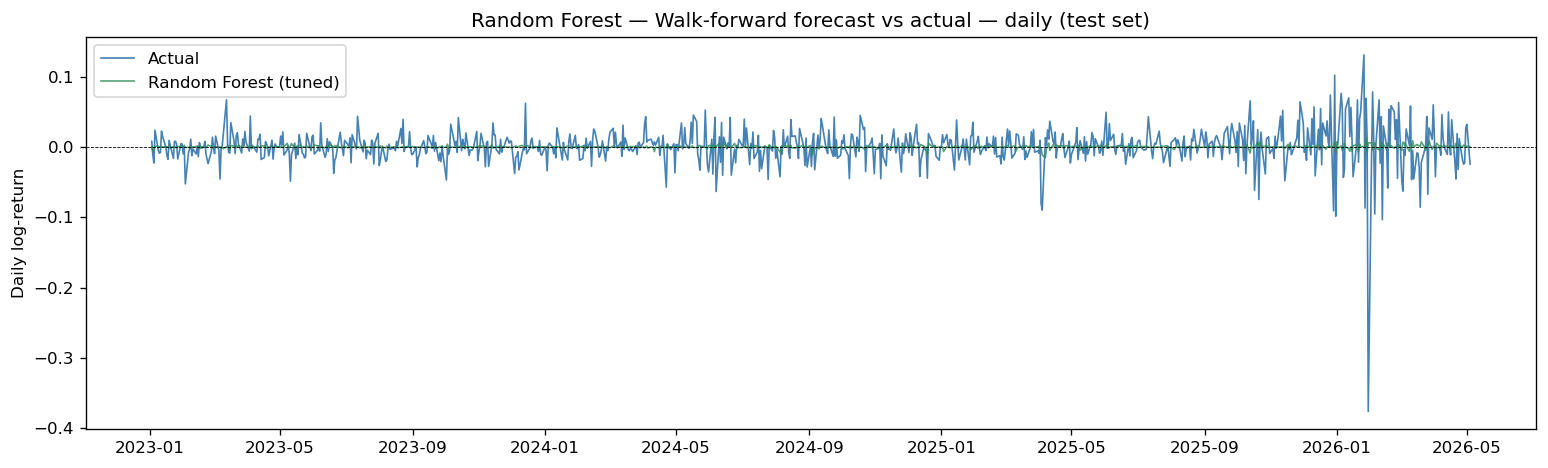

In [7]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test_index, y_test,  lw=1, label='Actual',               color='steelblue')
ax.plot(test_index, preds_rf, lw=1, label='Random Forest (tuned)', color='seagreen', alpha=0.8)
ax.axhline(0, color='black', lw=0.5, ls='--')
ax.set_title('Random Forest — Walk-forward forecast vs actual — daily (test set)')
ax.set_ylabel('Daily log-return')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Feature importance

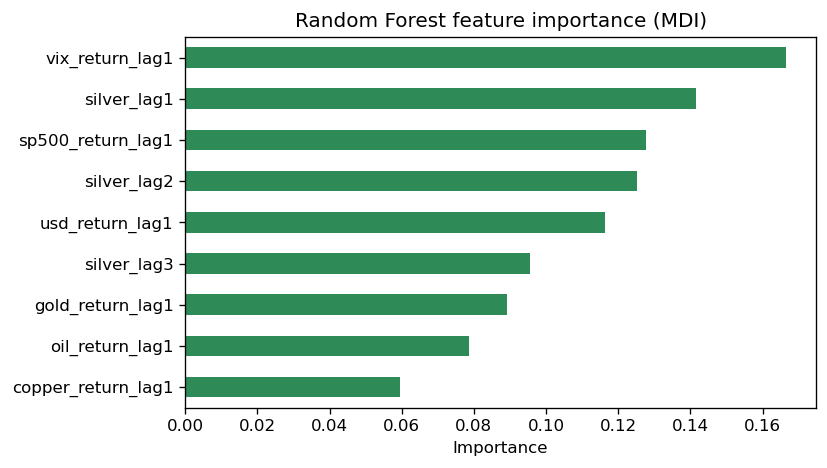

vix_return_lag1       0.166476
silver_lag1           0.141463
sp500_return_lag1     0.127595
silver_lag2           0.125158
usd_return_lag1       0.116258
silver_lag3           0.095569
gold_return_lag1      0.089213
oil_return_lag1       0.078605
copper_return_lag1    0.059663
dtype: float64


In [8]:
X_all = features_all[feature_cols].values
y_all = all_w[TARGET].values
mask  = ~np.isnan(X_all[:n_train]).any(axis=1)

final_model = RandomForestRegressor(random_state=42, n_jobs=-1, **best_params)
final_model.fit(X_all[:n_train][mask], y_all[:n_train][mask])

importances = pd.Series(final_model.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot.barh(ax=ax, color='seagreen')
ax.set_title('Random Forest feature importance (MDI)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()
print(importances.sort_values(ascending=False))

## 8. Sentiment comparison

Re-runs the walk-forward adding lagged weekly Reddit and news sentiment as extra features.
Compares DA and WDA with and without sentiment to test whether sentiment adds predictive value.

In [9]:
import os

sent_path = "../../data/processed/daily_sentiment.csv"
if not os.path.exists(sent_path):
    print("daily_sentiment.csv not found — run 03_sentiment.ipynb first.")
else:
    sentiment = pd.read_csv(sent_path, index_col=0, parse_dates=True)
    sent_w = sentiment[["reddit_sentiment", "news_sentiment"]].resample("B").mean()
    sent_w_lag = sent_w.shift(1)
    all_candidates = {}

    def tune(X_tr_s, y_tr_s, model_cls):
        mask_s = ~np.isnan(X_tr_s).any(axis=1)
        X_tr_s, y_tr_s = X_tr_s[mask_s], y_tr_s[mask_s]
        best_rmse_s, best_params_s = np.inf, {}
        for combo in combos:
            params = dict(zip(keys, combo))
            fold_rmses = []
            for fold_tr, fold_val in tscv.split(X_tr_s):
                m = model_cls(random_state=42, n_jobs=-1, **params)
                m.fit(X_tr_s[fold_tr], y_tr_s[fold_tr])
                preds = m.predict(X_tr_s[fold_val])
                fold_rmses.append(np.sqrt(mean_squared_error(y_tr_s[fold_val], preds)))
            rmse = np.mean(fold_rmses)
            if rmse < best_rmse_s:
                best_rmse_s, best_params_s = rmse, params
        return best_params_s, best_rmse_s

    def run_sentiment(sent_cols, label, features_base, feature_cols_base):
        feats = features_base.copy()
        for col in sent_cols:
            feats[col + "_lag1"] = sent_w_lag[col].reindex(feats.index).ffill()
        fcols = feats.columns.tolist()
        X_tr_s = feats.iloc[:n_train][fcols].values
        y_tr_s = all_w[TARGET].iloc[:n_train].values
        params_s, _ = tune(X_tr_s, y_tr_s, RandomForestRegressor)
        p_exp = walk_forward(all_w, feats, n_train, fcols,            **params_s)
        p_rol = walk_forward(all_w, feats, n_train, fcols, window=500, **params_s)
        print("--- {} ---".format(label))
        evaluate("{} expanding".format(label),      y_test, p_exp)
        evaluate("{} rolling (500d)".format(label), y_test, p_rol)
        all_candidates["{} expanding".format(label)]      = p_exp
        all_candidates["{} rolling (500d)".format(label)] = p_rol

    print("--- No sentiment (baseline) ---")
    evaluate("No sentiment expanding",      y_test, preds_rf_exp)
    evaluate("No sentiment rolling (500d)", y_test, preds_rf_rol)
    all_candidates["No sentiment expanding"]      = preds_rf_exp
    all_candidates["No sentiment rolling (500d)"] = preds_rf_rol
    print()

    print("Tuning and running: Reddit + News...")
    run_sentiment(["reddit_sentiment", "news_sentiment"], "Reddit+News", features_all, feature_cols)
    print()

    print("Tuning and running: Reddit only...")
    run_sentiment(["reddit_sentiment"], "Reddit only", features_all, feature_cols)
    print()

    print("Tuning and running: News only (GDELT)...")
    run_sentiment(["news_sentiment"], "News only", features_all, feature_cols)

--- No sentiment (baseline) ---
No sentiment expanding                         RMSE=0.02665  MAE=0.01633  DA=0.490  WDA=0.516
No sentiment rolling (500d)                    RMSE=0.02684  MAE=0.01646  DA=0.500  WDA=0.530

Tuning and running: Reddit + News...
--- Reddit+News ---
Reddit+News expanding                          RMSE=0.02667  MAE=0.01637  DA=0.482  WDA=0.538
Reddit+News rolling (500d)                     RMSE=0.02698  MAE=0.01653  DA=0.489  WDA=0.500

Tuning and running: Reddit only...
--- Reddit only ---
Reddit only expanding                          RMSE=0.02668  MAE=0.01631  DA=0.495  WDA=0.528
Reddit only rolling (500d)                     RMSE=0.02688  MAE=0.01643  DA=0.498  WDA=0.520

Tuning and running: News only (GDELT)...
--- News only ---
News only expanding                            RMSE=0.02663  MAE=0.01634  DA=0.502  WDA=0.564
News only rolling (500d)                       RMSE=0.02688  MAE=0.01641  DA=0.506  WDA=0.536


## Sub-period robustness: DA and WDA by year

Breaks down the best-performing variant by calendar year to check whether
the result is stable across different market regimes.

In [10]:
best_name = max(all_candidates, key=lambda k:
    np.nansum(np.abs(y_test) * (np.sign(y_test) == np.sign(all_candidates[k]))) /
    np.nansum(np.abs(y_test)))
best_pred = all_candidates[best_name]
print("Best variant by WDA:", best_name)
res = period_metrics(y_test, best_pred, test_index, PERIODS)
display(res[["n", "DA", "WDA"]].style
        .format({"n": "{:.0f}", "DA": "{:.3f}", "WDA": "{:.3f}"})
        .background_gradient(cmap="RdYlGn", subset=["DA", "WDA"], vmin=0.4, vmax=0.7))
res[['n', 'DA', 'WDA']].to_csv('../../data/processed/period_rf_daily.csv')

Best variant by WDA: News only expanding


,n,DA,WDA
Period,,,
2023 (choppy),259,0.471,0.539
2024 (bull start),262,0.542,0.580
2025 (bull run),261,0.513,0.602
2026 (YTD),88,0.443,0.523
── Full test ──,870,0.502,0.564


## Diebold-Mariano test

Tests whether sentiment variants produce statistically significant forecast improvements
over the no-sentiment baseline. H0: equal predictive accuracy (squared error loss).
p < 0.05 = significant improvement.

In [11]:
print("Diebold-Mariano tests — each variant vs no-sentiment baseline")
print("H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns=not significant")
print("-" * 90)

baseline_key  = "No sentiment expanding"
baseline_pred = all_candidates[baseline_key]
for name, pred in all_candidates.items():
    if name == baseline_key:
        continue
    diebold_mariano(y_test, baseline_pred, pred, baseline_key, name)

Diebold-Mariano tests — each variant vs no-sentiment baseline
H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns=not significant
------------------------------------------------------------------------------------------
No sentiment expanding                   vs No sentiment rolling (500d)               DM=-1.181  p=0.238  (ns)
No sentiment expanding                   vs Reddit+News expanding                     DM=-0.379  p=0.704  (ns)
No sentiment expanding                   vs Reddit+News rolling (500d)                DM=-1.468  p=0.142  (ns)
No sentiment expanding                   vs Reddit only expanding                     DM=-0.504  p=0.614  (ns)
No sentiment expanding                   vs Reddit only rolling (500d)                DM=-1.131  p=0.258  (ns)
No sentiment expanding                   vs News only expanding                       DM=+0.533  p=0.594  (ns)
No sentiment expanding                   vs News only rolling (500d)                  DM=-1.11

## 2026 zoom — actual vs best model

Focuses on the most recent out-of-sample period where silver has been most active.
Uses the best-performing variant selected earlier.

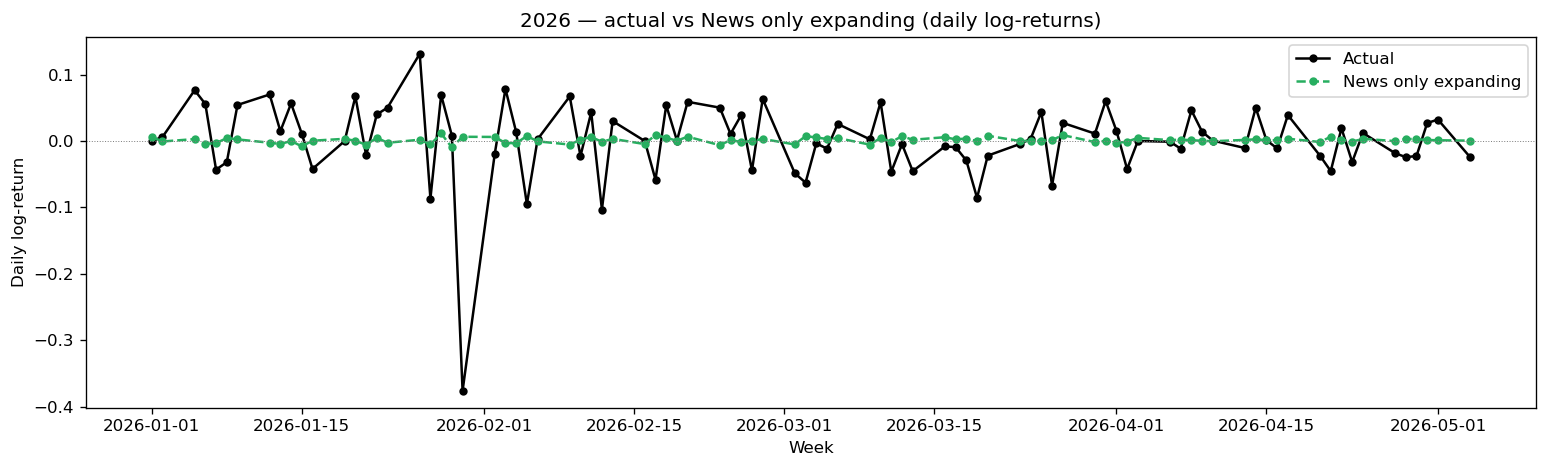

In [12]:
df26 = pd.DataFrame({"actual": y_test, "pred": best_pred}, index=test_index)
df26 = df26.loc["2026":]

if df26.empty:
    print("No 2026 data in test set yet.")
else:
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(df26.index, df26["actual"], color="black",  lw=1.5, marker="o", ms=4, label="Actual")
    ax.plot(df26.index, df26["pred"],   color="#27ae60", lw=1.5, marker="o", ms=4,
            ls="--", label=f"{best_name}")
    ax.axhline(0, color="grey", lw=0.6, ls=":")
    ax.set_title(f"2026 — actual vs {best_name} (daily log-returns)", fontsize=12)
    ax.set_ylabel("Daily log-return")
    ax.set_xlabel("Week")
    ax.legend()
    plt.tight_layout()
    plt.show()